# Ocean Carbon Sampling
## A map-first visual story of fixed-sample-count observing strategies

<div style="padding:16px 18px;border-left:5px solid #0F766E;background:#F0FDFA;">
<b>Question</b><br>At a fixed annual sample count, can changing <i>where and when</i> we sample redistribute—or systematically shift—global monthly reconstruction error?
</div>

**Demo status:** scientific content is source-grounded; layout remains open for portfolio refinement.

In [1]:
from pathlib import Path

import pandas as pd

from ocean_carbon_sampling.demo_visuals import (
    plot_budget_sweep,
    plot_error_atlas,
    plot_historical_bias_atlas,
    plot_historical_bias_atlas,
    plot_sampling_atlas,
    plot_spatial_holdout_gate,
)

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
RESULTS = ROOT / 'results' / 'public'
fields = pd.read_parquet(RESULTS / 'osse_visual_demo_fields.parquet')
sampling = pd.read_parquet(RESULTS / 'osse_visual_demo_sampling.parquet')
metadata = pd.read_csv(RESULTS / 'osse_visual_demo_metadata.csv')
effects = pd.read_csv(RESULTS / 'osse_cross_year_paired_summary.csv')
regrid = pd.read_csv(RESULTS / 'osse_regrid_audit_paired_summary.csv')
spatial_blocks = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_blocks.csv')
spatial_summary = pd.read_csv(RESULTS / 'osse_spatial_block_confirmatory_paired_summary.csv')
month_balance = pd.read_csv(RESULTS / 'osse_month_balance_strategy_summary.csv')
claim_summary = pd.read_csv(RESULTS / 'osse_claim_distribution_summary.csv')
truth_scale = pd.read_csv(RESULTS / 'osse_truth_scale.csv')
historical_month_balance = pd.read_csv(
    RESULTS / 'osse_historical_month_balance_distribution_summary.csv'
)
historical_month_balance_selections = pd.read_csv(
    RESULTS / 'osse_historical_month_balance_selections.csv'
)
historical_bias_map = pd.read_parquet(
    RESULTS / 'osse_historical_bias_map_2005.parquet'
)
historical_month_balance = pd.read_csv(
    RESULTS / 'osse_historical_month_balance_distribution_summary.csv'
)
historical_month_balance_selections = pd.read_csv(
    RESULTS / 'osse_historical_month_balance_selections.csv'
)
historical_bias_map = pd.read_parquet(
    RESULTS / 'osse_historical_bias_map_2005.parquet'
)
print('Curated visual-demo data loaded.')

Curated visual-demo data loaded.


In [2]:
metadata.rename(columns={
    'complete_month_cells': 'complete month-grid cells',
    'evaluation_month_cells': 'hidden evaluation rows',
    'map_grid_cells': 'mapped spatial cells',
})

,year,seed,error_map_seeds,n_error_map_seeds,budget,complete month-grid cells,candidate_month_cells,hidden evaluation rows,mapped spatial cells,sampling_longitude_degrees,sampling_latitude_degrees,map_role
0,2005,0,0;1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;19,20,5000,487488,390000,97488,40624,10.0,5.0,error fields are paired-seed means; sampling g...


## 0 · What is being predicted—and why monthly?

This project evaluates **reconstruction under a fixed annual sample count**, not future-time forecasting. The truth field is monthly surface-ocean `spco2` from the CMIP6 IPSL-CM6A-LR historical Earth-system-model simulation (`r1i1p1f1`)—not a SOCAT-derived reconstruction. SST and salinity from the same simulation are predictors; SOCAT only defines the historical observing-pattern baseline.

Each record is a month–location observation, but all 12 months are fitted jointly in one model. Cyclic month features preserve the seasonal cycle and keep December adjacent to January.

The random hidden set is stratified by month so every season has the same evaluation fraction; otherwise seasonal test composition could be mistaken for a sampling-strategy effect. In the stricter spatial holdout, all 12 months from one location stay in the same fold, preventing the model from training on another month at the evaluation location. A chronological split would instead test forecasting under temporal distribution shift—a valid but different question.

In [3]:
month_balance_appendix = month_balance.query('budget == 5000').assign(
    strategy=lambda frame: frame['strategy'].replace({
        'random': 'Random',
        'spatial_coverage': 'Seasonally balanced spatial coverage',
        'historical_density': 'Historical spatiotemporal pattern',
    }),
    mean_abs_equal_deviation_pp=lambda frame: frame['mean_abs_equal_deviation_pp'].round(3),
    mean_max_abs_equal_deviation_pp=lambda frame: frame['mean_max_abs_equal_deviation_pp'].round(3),
)[['strategy', 'n_year_fold_seed_selections', 'minimum_months_covered',
   'mean_abs_equal_deviation_pp', 'mean_max_abs_equal_deviation_pp']]

balanced_month_audit = pd.DataFrame([{
    'strategy': 'Historical spatial marginal × uniform month',
    'n_year_fold_seed_selections': len(historical_month_balance_selections),
    'minimum_months_covered': 12,
    'mean_abs_equal_deviation_pp': historical_month_balance_selections['mean_abs_equal_deviation_pp'].mean(),
    'mean_max_abs_equal_deviation_pp': historical_month_balance_selections['maximum_abs_equal_deviation_pp'].mean(),
}]).round(3)
month_balance_appendix = pd.concat(
    [month_balance_appendix, balanced_month_audit], ignore_index=True
)

A selection-only audit confirms that all 1,800 selections cover all 12 months and that random and coverage have closely matched month shares. The detailed audit is moved to the appendix. Historical density remains a realistic **spatiotemporal** baseline, not a pure spatial control.

## 1 · Same sample count, different observing geometry

Each strategy selects exactly 5,000 month-grid observations from the same candidate pool. Random and seasonally balanced spatial coverage have closely matched monthly allocation, so this map isolates their main difference: where observations are placed. Colour encodes the number selected within each 5° × 10° spatial block; no observations are discarded for plotting.

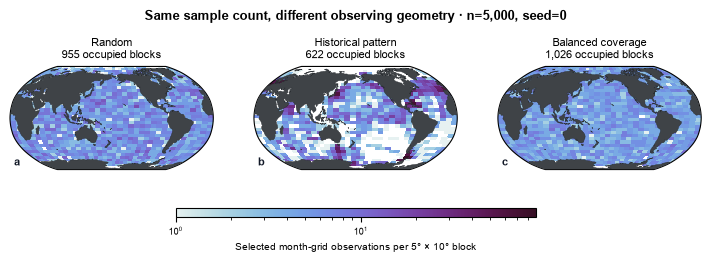

In [4]:
sampling_figure = plot_sampling_atlas(sampling, budget=5000, seed=0)

<div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:10px;margin:10px 0 22px 0;">
<div style="padding:10px;background:#F9FAFB;border-radius:6px;"><b>Random</b><br>Broad but uneven by chance.</div>
<div style="padding:10px;background:#FFF7ED;border-radius:6px;"><b>Historical pattern</b><br>Reproduces seasonal and spatial observation density.</div>
<div style="padding:10px;background:#F0FDFA;border-radius:6px;"><b>Balanced spatial coverage</b><br>Cycles across month × under-filled spatial blocks.</div>
</div>

## 2 · Where do strategy effects appear?

### Strong comparison · Historical pattern versus its month-balanced control

The first two maps show 2005 local mean signed error across all hidden evaluation months available at each location and all 20 paired seeds. The control preserves the SOCAT-derived historical **spatial marginal**, forces exact uniform month quotas, and removes the historical space–month interaction. Stippling marks locations with negative local mean error in at least 16/20 seeds. The third panel shows where factorization changes signed error. Colours are clipped at the 98th percentile for contrast; all values remain in metrics.

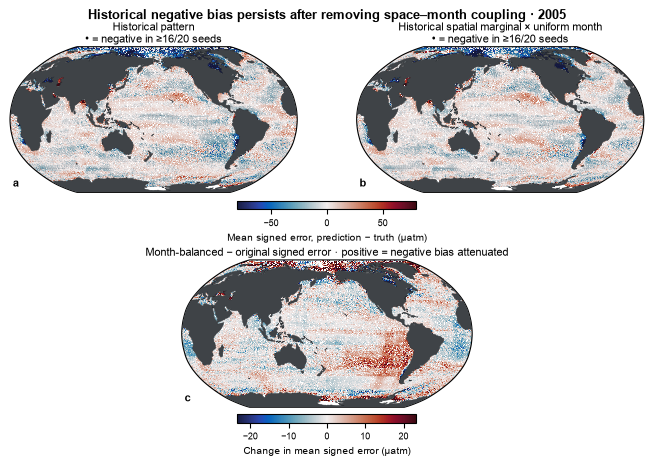

In [5]:
historical_bias_figure = plot_historical_bias_atlas(historical_bias_map)

In [6]:
original_historical = claim_summary.query(
    "budget == 5000 and comparison == 'historical_density_minus_random' and "
    "metric in ['bias', 'rmse', 'p99_absolute_error']"
).assign(
    design='Observed historical space × month',
    comparator_value=lambda frame: frame['mean_comparator_value'],
)[[
    'validation_scheme', 'design', 'metric', 'mean_random_baseline',
    'comparator_value', 'mean_difference', 'n_units',
    'units_below_zero', 'units_above_zero',
]]
factorized_historical = historical_month_balance.query(
    "metric in ['bias', 'rmse', 'p99_absolute_error']"
).assign(
    design='Historical spatial marginal × uniform month',
    mean_random_baseline=lambda frame: frame['mean_random'],
    comparator_value=lambda frame: frame['mean_comparator'],
)[[
    'validation_scheme', 'design', 'metric', 'mean_random_baseline',
    'comparator_value', 'mean_difference', 'n_units',
    'units_below_zero', 'units_above_zero',
]]
historical_identification = pd.concat(
    [original_historical, factorized_historical], ignore_index=True
).assign(
    validation=lambda frame: frame['validation_scheme'].replace({
        'month_stratified_hidden_cells': 'Hidden cells',
        'whole_spatial_blocks': 'Whole blocks',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    comparator=lambda frame: frame['comparator_value'].round(3),
    difference=lambda frame: frame['mean_difference'].round(3),
)[[
    'validation', 'design', 'metric', 'n_units', 'random', 'comparator',
    'difference', 'units_below_zero', 'units_above_zero',
]]
historical_identification.sort_values(['validation', 'metric', 'design'])

,validation,design,metric,n_units,random,comparator,difference,units_below_zero,units_above_zero
6,Hidden cells,Historical spatial marginal × uniform month,bias,3,0.065,-3.798,-3.863,3,0
0,Hidden cells,Observed historical space × month,bias,3,0.065,-4.822,-4.887,3,0
7,Hidden cells,Historical spatial marginal × uniform month,p99_absolute_error,3,66.406,112.739,46.333,0,3
1,Hidden cells,Observed historical space × month,p99_absolute_error,3,66.406,127.954,61.548,0,3
8,Hidden cells,Historical spatial marginal × uniform month,rmse,3,25.936,34.299,8.363,0,3
2,Hidden cells,Observed historical space × month,rmse,3,25.936,35.801,9.865,0,3
9,Whole blocks,Historical spatial marginal × uniform month,bias,15,0.104,-3.736,-3.839,15,0
3,Whole blocks,Observed historical space × month,bias,15,0.104,-4.851,-4.954,15,0
10,Whole blocks,Historical spatial marginal × uniform month,p99_absolute_error,15,80.367,120.579,40.212,0,15
4,Whole blocks,Observed historical space × month,p99_absolute_error,15,80.367,128.309,47.942,0,15


**Identification result.** Exact month balancing attenuates but does not remove the historical penalty. Under whole-block validation, the bias difference changes from −4.954 to **−3.839 µatm**; **77.5%** of its original magnitude remains, and all **15/15** units are still negative. The RMSE penalty remains +7.594 µatm (85.0% of the original +8.936), and the p99 penalty remains +40.212 µatm (83.9% of +47.942). Hidden-cell bias gives the same conclusion: −3.863 µatm remains, with 3/3 years negative.

Within this locked model, the historical spatial marginal is therefore sufficient to reproduce most of the negative bias and magnitude penalty. Space–month coupling contributes materially—the whole-block bias is attenuated by 1.115 µatm—but it is not the primary explanation. The map localises the bias geography; it does not by itself prove that local sampling density caused each regional error. Its cells are descriptive, not independent replicates, and their unweighted visual average is not the reported global metric.

### Bounded comparison · Coverage versus random

The coverage hero panel uses every row of the locked 2005 hidden evaluation set and averages absolute error over all 20 paired seeds. Blue cells favour coverage; red cells favour random. Stippling marks cells where at least 16/20 seed-level spatial ΔMAE values share the same sign. The lower row now includes historical absolute error so visual weight matches its larger numerical penalty.

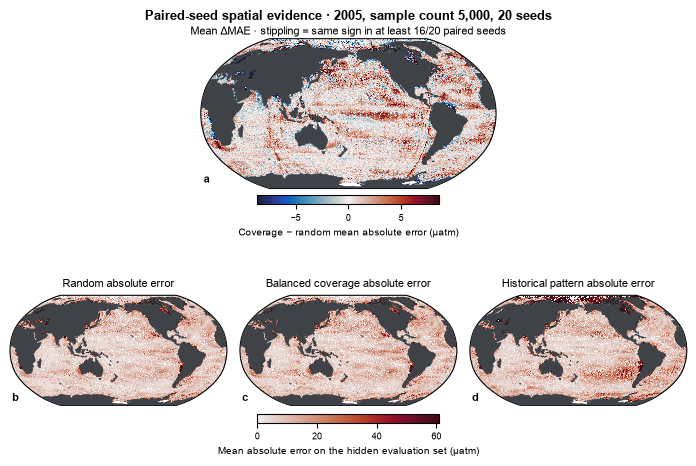

In [7]:
error_figure = plot_error_atlas(fields)

**Reading boundary.** The coverage map uses 2005 and sample count 5,000 to localise the 20-seed paired effect. It is quantitative spatial evidence, but grid cells are not independent replicates; inference remains at the paired-seed and year–fold levels.

## 3 · Absolute scale and sample-count boundary

Differences are interpretable only beside their absolute baselines and the intrinsic scale of the truth field. The first table gives a no-extra-assumptions reference from the locked `spco2` truth fields. The second reports random and comparator absolute errors, their differences, and percentage changes at sample count 5,000. Signed-bias percentages are undefined because the random denominators are near zero.

The figure then uses every locked sample count (500, 1,000, 2,500 and 5,000), all 20 paired sampling seeds and each of three prespecified years. Points are paired-seed mean differences and intervals are 10,000-resample seed-bootstrap 95% intervals. The metrics and years are correlated views of the same experiment, not independent tests.

In [8]:
truth_scale.query("scope == 'pooled_prespecified_years'").assign(
    month_cell_standard_deviation_uatm=lambda frame: frame['month_cell_standard_deviation_uatm'].round(1),
    annual_mean_spatial_standard_deviation_uatm=lambda frame: frame['annual_mean_spatial_standard_deviation_uatm'].round(1),
    median_local_seasonal_amplitude_uatm=lambda frame: frame['median_local_seasonal_amplitude_uatm'].round(1),
)[[
    'scope', 'n_finite_month_cells', 'month_cell_standard_deviation_uatm',
    'annual_mean_spatial_standard_deviation_uatm',
    'median_local_seasonal_amplitude_uatm',
]]

,scope,n_finite_month_cells,month_cell_standard_deviation_uatm,annual_mean_spatial_standard_deviation_uatm,median_local_seasonal_amplitude_uatm
3,pooled_prespecified_years,1462464,44.9,31.0,58.8


**How to read this scale.** The hidden-cell coverage–random RMSE difference of 1.107 µatm is about **2.5%** of the pooled month-cell truth standard deviation (44.9 µatm), whereas the whole-block historical–random difference of 8.936 µatm is about **20%**. These ratios place the bounded coverage effect and the much larger historical-pattern penalty on the same physical scale.

The random hidden-cell RMSE of 25.936 µatm compared with the 44.9 µatm truth standard deviation corresponds to a rough variance-explained reference of $1-(25.936/44.9)^2 \approx 0.67$. This is **not** an exactly recomputed pooled $R^2$ because the RMSE and truth standard deviation use different aggregations. It nevertheless shows that substantial residual error is conditioned by the reconstruction method as well as sampling geometry, making cross-model replication the most important next robustness test.

In [9]:
absolute_scale = claim_summary.query('budget == 5000').assign(
    validation=lambda frame: frame['validation_scheme'].replace({
        'month_stratified_hidden_cells': 'Hidden cells',
        'whole_spatial_blocks': 'Whole blocks',
    }),
    comparator=lambda frame: frame['comparison'].replace({
        'spatial_coverage_minus_random': 'Coverage',
        'historical_density_minus_random': 'Historical pattern',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    comparator_value=lambda frame: frame['mean_comparator_value'].round(3),
    difference=lambda frame: frame['mean_difference'].round(3),
    relative_change_percent=lambda frame: frame['mean_relative_error_change_percent'].round(2),
)[[
    'validation', 'comparator', 'metric', 'random', 'comparator_value',
    'difference', 'relative_change_percent',
]]
absolute_scale.sort_values(['validation', 'comparator', 'metric'])

,validation,comparator,metric,random,comparator_value,difference,relative_change_percent
42,Hidden cells,Coverage,bias,0.065,0.071,0.006,NaN
43,Hidden cells,Coverage,mae,10.936,11.436,0.500,4.56
44,Hidden cells,Coverage,median_absolute_error,7.083,7.754,0.670,9.47
45,Hidden cells,Coverage,p95_absolute_error,30.696,31.785,1.090,3.55
46,Hidden cells,Coverage,p99_absolute_error,66.406,61.686,-4.720,-7.10
47,Hidden cells,Coverage,rmse,25.936,24.829,-1.107,-4.23
36,Hidden cells,Historical pattern,bias,0.065,-4.822,-4.887,NaN
37,Hidden cells,Historical pattern,mae,10.936,16.366,5.430,49.65
38,Hidden cells,Historical pattern,median_absolute_error,7.083,9.057,1.974,27.85
39,Hidden cells,Historical pattern,p95_absolute_error,30.696,56.371,25.676,83.72


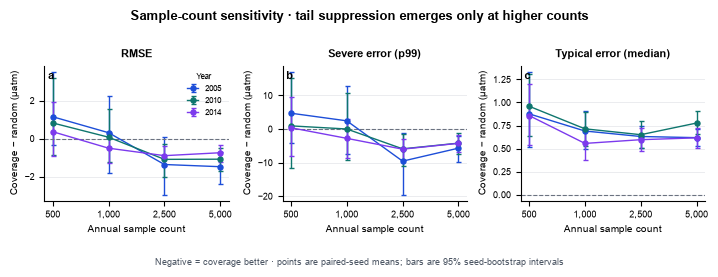

In [10]:
key_effects = effects.query(
    "evaluation_domain == 'all' and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
).copy()
budget_sweep_figure = plot_budget_sweep(key_effects)

In [11]:
key_effects.query('budget == 5000').assign(
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    seed_bootstrap_low=lambda frame: frame['seed_bootstrap_low'].round(3),
    seed_bootstrap_high=lambda frame: frame['seed_bootstrap_high'].round(3),
)[[
    'year', 'metric', 'n_seeds', 'mean_difference',
    'seed_bootstrap_low', 'seed_bootstrap_high',
]].sort_values(['metric', 'year'])

,year,metric,n_seeds,mean_difference,seed_bootstrap_low,seed_bootstrap_high
36,2005,median_absolute_error,20,0.618,0.525,0.709
116,2010,median_absolute_error,20,0.777,0.655,0.904
196,2014,median_absolute_error,20,0.616,0.509,0.726
38,2005,p99_absolute_error,20,-5.701,-9.844,-1.952
118,2010,p99_absolute_error,20,-4.207,-7.562,-1.113
198,2014,p99_absolute_error,20,-4.253,-6.767,-1.877
39,2005,rmse,20,-1.484,-2.376,-0.701
119,2010,rmse,20,-1.088,-1.705,-0.507
199,2014,rmse,20,-0.749,-1.213,-0.315


**Sample-count boundary.** At 500 observations, coverage is worse than random in all three years not only through the median but also at p99 and RMSE: extreme-tail suppression has not yet emerged. At 1,000, the p99 and RMSE directions are mixed across years. At 2,500 and 5,000, mean p99 falls in all three years, while median error remains higher at every tested count. Coverage therefore lowers the extreme tail while raising the more common sub-p95 error range only after the sample count is sufficiently high; this is not a count-invariant advantage.

### Supporting audit · Spatial weighting

At sample count 5,000, replacing equal weighting within one-degree bins with native-cell-area weighting preserves the directions of the three displayed coverage-versus-random metrics. These correlated metrics are an audit of one result, not independent tests.

In [12]:
audit_filter = (
    "evaluation_domain == 'all' and budget == 5000 and "
    "comparison == 'spatial_coverage_minus_random' and "
    "metric in ['rmse', 'p99_absolute_error', 'median_absolute_error']"
)
equal_bin = key_effects.query('budget == 5000').assign(method='equal-bin baseline')
area_weighted = regrid.query(audit_filter).assign(method='native-cell-area audit')
robustness = pd.concat([equal_bin, area_weighted], ignore_index=True)
robustness.pivot_table(
    index=['year', 'metric'], columns='method', values='mean_difference'
).round(3)

method                      equal-bin baseline  native-cell-area audit
year metric                                                           
2005 median_absolute_error               0.618                   0.637
     p99_absolute_error                 -5.701                  -5.693
     rmse                               -1.484                  -1.464
2010 median_absolute_error               0.777                   0.747
     p99_absolute_error                 -4.207                  -5.025
     rmse                               -1.088                  -1.153
2014 median_absolute_error               0.616                   0.594
     p99_absolute_error                 -4.253                  -4.264
     rmse                               -0.749                  -0.692

## 4 · Stricter validation: whole regions unseen

### What is a Global spatial-block holdout OSSE?

An **OSSE** (Observing System Simulation Experiment) treats a complete climate-model field as known truth, simulates where observations would be collected, reconstructs the unsampled ocean, and scores that reconstruction against the truth. A **spatial-block holdout** makes the test harder: instead of hiding scattered cells, it withholds whole geographic blocks. The model therefore cannot learn from another month at the same location or from a randomly hidden neighbour inside the held-out block.

Here, all 12 months of each 20° × 10° block stay together. Five checkerboard folds exhaust the occupied ocean blocks: one fold is evaluated while the other four provide candidates, repeated until every block has been held out once. The confirmatory comparison repeats this design in the prespecified years 2005, 2010 and 2014, using the same model, equal sample counts, 20 paired sampling seeds per year–fold, and seed-bootstrap intervals. There is no extra buffer around held-out blocks, so this is a coarse unseen-region gate rather than a long-range extrapolation test.

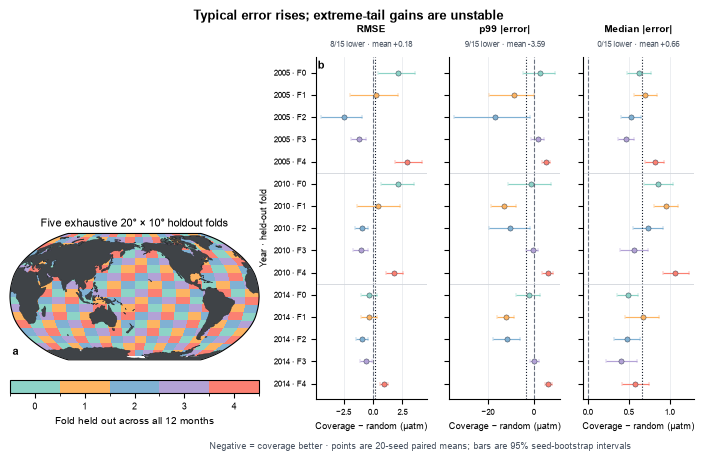

In [13]:
spatial_gate_figure = plot_spatial_holdout_gate(spatial_blocks, spatial_summary)

**One mechanism under both validation schemes.** At sample count 5,000, coverage raises median, MAE and p95 error in essentially every whole-block unit: MAE and median are higher in 15/15, and p95 is higher in 14/15. Its mean p99 difference is **−3.590 µatm**, but only 9/15 units favour coverage; this tail benefit is not directionally stable. RMSE is lower in 8/15 and higher in 7/15, with a descriptive mean of **+0.179 µatm**.

The same distributional shift already appears in random hidden cells: coverage is worse through p95 but better at p99. Because RMSE squares errors, its hidden-cell improvement is driven by those rare large errors and is not evidence of broad improvement across the error distribution. Whole-block validation does not reveal a separate regime; it shows that the extreme-tail benefit becomes unstable when complete regions are unseen. Negative differences favour coverage.

The 15 year–fold units are a descriptive consistency check, not independent replicates; the three years share persistent spatial structure because they come from the same model run.

## 5 · Whole-block distributions and signed bias

The table exposes all 15 year–fold units for both coverage and the historical observing pattern. It reports absolute random and comparator means alongside the distribution of paired differences, so large means cannot hide directional inconsistency.

In [14]:
whole_block_distribution = claim_summary.query(
    "validation_scheme == 'whole_spatial_blocks' and budget == 5000"
).assign(
    comparator=lambda frame: frame['comparison'].replace({
        'spatial_coverage_minus_random': 'Coverage',
        'historical_density_minus_random': 'Historical pattern',
    }),
    random=lambda frame: frame['mean_random_baseline'].round(3),
    comparator_value=lambda frame: frame['mean_comparator_value'].round(3),
    mean_difference=lambda frame: frame['mean_difference'].round(3),
    median=lambda frame: frame['median_difference'].round(3),
    q25=lambda frame: frame['q25_difference'].round(3),
    q75=lambda frame: frame['q75_difference'].round(3),
    minimum=lambda frame: frame['minimum_difference'].round(3),
    maximum=lambda frame: frame['maximum_difference'].round(3),
)[[
    'comparator', 'metric', 'n_units', 'random', 'comparator_value',
    'mean_difference', 'median', 'q25', 'q75', 'minimum', 'maximum',
    'units_below_zero', 'units_above_zero',
]]
whole_block_distribution.sort_values(['comparator', 'metric'])

,comparator,metric,n_units,random,comparator_value,mean_difference,median,q25,q75,minimum,maximum,units_below_zero,units_above_zero
66,Coverage,bias,15,0.104,0.256,0.152,0.320,-0.429,0.557,-0.657,1.017,6,9
67,Coverage,mae,15,12.828,13.460,0.632,0.550,0.383,0.815,0.160,1.379,0,15
68,Coverage,median_absolute_error,15,8.295,8.958,0.663,0.626,0.509,0.775,0.409,1.069,0,15
69,Coverage,p95_absolute_error,15,36.588,37.846,1.257,1.273,0.601,1.635,-0.023,3.055,1,14
70,Coverage,p99_absolute_error,15,80.367,76.777,-3.590,-1.002,-11.106,2.207,-16.788,6.294,9,6
71,Coverage,rmse,15,27.549,27.728,0.179,-0.321,-0.940,1.368,-2.496,2.922,8,7
60,Historical pattern,bias,15,0.104,-4.851,-4.954,-5.257,-5.613,-4.316,-6.188,-3.358,15,0
61,Historical pattern,mae,15,12.828,17.809,4.981,4.835,4.550,5.400,3.910,6.131,0,15
62,Historical pattern,median_absolute_error,15,8.295,10.382,2.087,2.138,1.946,2.220,1.468,2.554,0,15
63,Historical pattern,p95_absolute_error,15,36.588,59.571,22.982,23.125,19.051,25.983,15.565,31.460,0,15


The observed historical pattern has two distinct legs. **Magnitude:** whole-block RMSE rises from **27.549 to 36.486 µatm** (+8.936), with historical worse in **15/15** year–fold units; in hidden cells, p99 rises from **66.406 to 127.954 µatm**, nearly doubling. **Direction:** historical reconstruction has a stable negative global signed error—**−4.822 µatm** in hidden cells and **−4.851 µatm** in whole blocks, versus +0.065 and +0.104 µatm for random.

The factorized audit separates the main alternative explanation. After retaining the historical spatial marginal but enforcing exact 1/12 month quotas at every run, whole-block bias remains **−3.736 µatm** (difference from random −3.839) and is negative in **15/15** units. Thus most of the historical bias survives removal of both global month imbalance and space–month interaction; the attenuation from −4.954 to −3.839 shows that seasonal coupling still contributes. This supports a spatial interpretation under the locked model without claiming that seasonality is irrelevant.

Unlike absolute-error magnitudes, a signed global offset is not removed by positive–negative cancellation within the evaluated mean and can propagate directionally into a downstream air–sea flux estimate. Quantifying that flux impact still requires a locked flux operator, so no PgC yr⁻¹ conversion is claimed.

The redistribution statement applies specifically to **coverage versus random**. Their global mean signed errors remain tiny beside RMSE: +0.065 versus +0.071 µatm in hidden cells and +0.104 versus +0.256 µatm in whole blocks. Coverage primarily changes the error-magnitude distribution rather than introducing a global signed offset; near-zero global bias does not rule out cancelling regional biases.

---
## Appendix · Monthly allocation audit

This table is a design audit, not part of the main inferential sequence. It reconstructs all 1,800 acquisition choices without additional model fitting. Deviation values are percentage points from an equal one-twelfth monthly share.

In [15]:
month_balance_appendix

,strategy,n_year_fold_seed_selections,minimum_months_covered,mean_abs_equal_deviation_pp,mean_max_abs_equal_deviation_pp
0,Historical spatiotemporal pattern,300,12,0.875,2.506
1,Random,300,12,0.292,0.754
2,Seasonally balanced spatial coverage,300,12,0.222,0.532
3,Historical spatial marginal × uniform month,360,12,0.009,0.013


---
## Result

<div style="padding:18px;background:#111827;color:#F9FAFB;border-radius:8px;font-size:16px;line-height:1.45;">
The historical spatial marginal is sufficient to reproduce most of the large error penalty and negative pCO₂ bias; removing space–month coupling attenuates but does not eliminate either. Balanced coverage is nearly unbiased but trades lower extreme-tail error for higher sub-p95 error, with unstable tail gains in unseen regions.
</div>

**Strong result:** the observed historical pattern raises whole-block RMSE by 8.936 µatm, nearly doubles hidden-cell p99, and introduces an approximately −4.85 µatm global signed bias. A factorized control preserving only its spatial marginal retains a −3.839 µatm whole-block bias difference (77.5% of the original magnitude), a +7.594 µatm RMSE penalty, and negative bias in 15/15 units. Seasonal coupling contributes, but does not explain most of the result under this model.  
**Bounded result:** coverage lowers the extreme tail while raising median, MAE and p95 error. Its hidden-cell RMSE decrease is tail-sensitive evidence, not an independent sign of broad improvement; under whole-block validation the p99 mean favours coverage in only 9/15 units.  
**Not yet supported:** a numerical integrated-flux effect, universal superiority, buffered extrapolation, cost-aware design, cross-model robustness, or direct real-ocean performance.